[2026-07-10 03:13:02] [info     ] 计算因子，测试区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-10 03:13:03] [info     ] 开始构建训练集                        train_end='2023-12-31 23:59:59' train_start='2019-01-01 00:00:00'
[2026-07-10 03:13:03] [info     ] build_features 开始              end='2023-12-31 23:59:59' start='2019-01-01 00:00:00'
[2026-07-10 03:13:03] [info     ] 财务原始字段查询完成                     elapsed=0.24 rows=45094
[2026-07-10 03:14:40] [info     ] 量价原始字段查询完成                     elapsed=96.67 rows=2389640
[2026-07-10 03:14:40] [info     ] 标签计算完成                         elapsed=0.36
[2026-07-10 03:14:41] [info     ] 财务日历填充完成                       total_calendar=4993289
[2026-07-10 03:14:48] [info     ] BARRA暴露合并完成                    elapsed=4.87 exp_cols=46
[2026-07-10 03:14:55] [info     ] 日行情合并完成                        elapsed=7.02 new_cols=5
[2026-07-10 03:15:03] [info     ] 缺失值处理完成                        elapsed=8.54
[2026-07-10 03:15:05] [info     ] build_features 结束         

时段,IC
2024-01-15~2024-02-08,-0.0025
2024-09-24~2024-10-08,0.0423

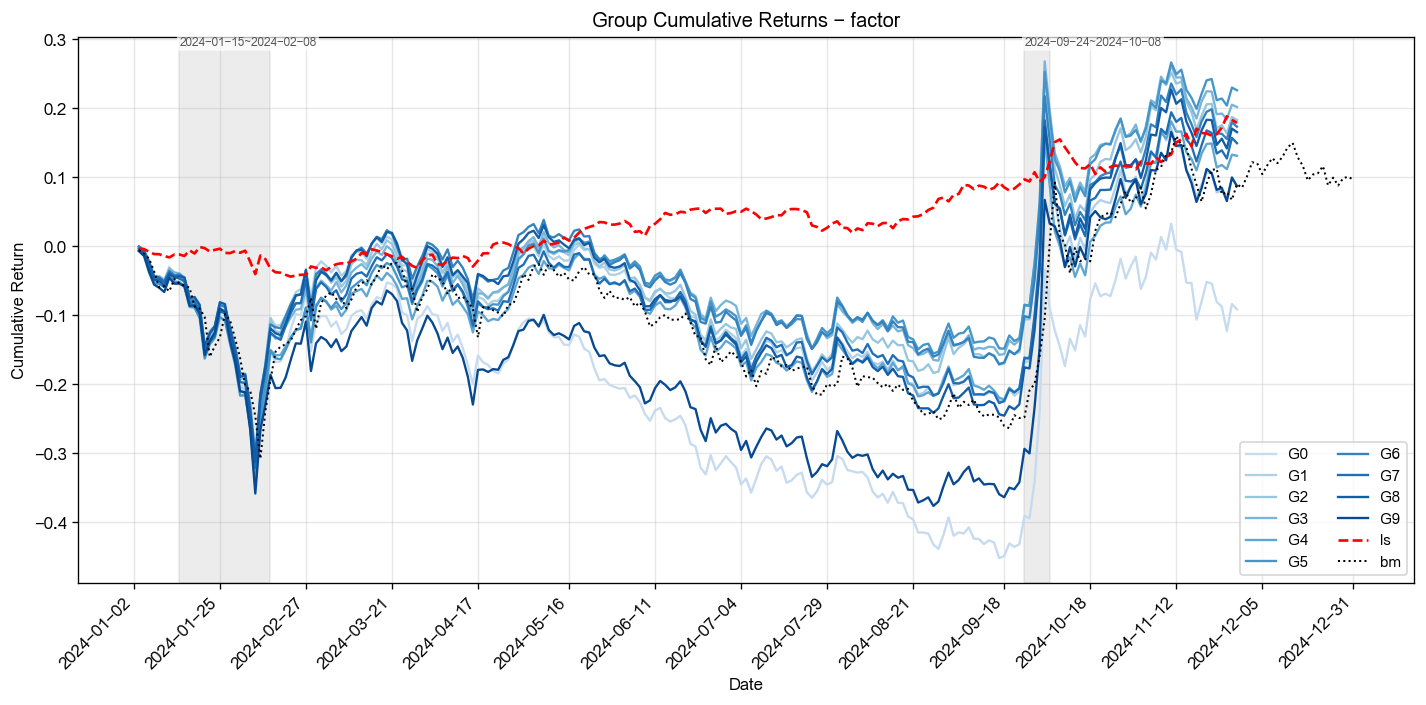
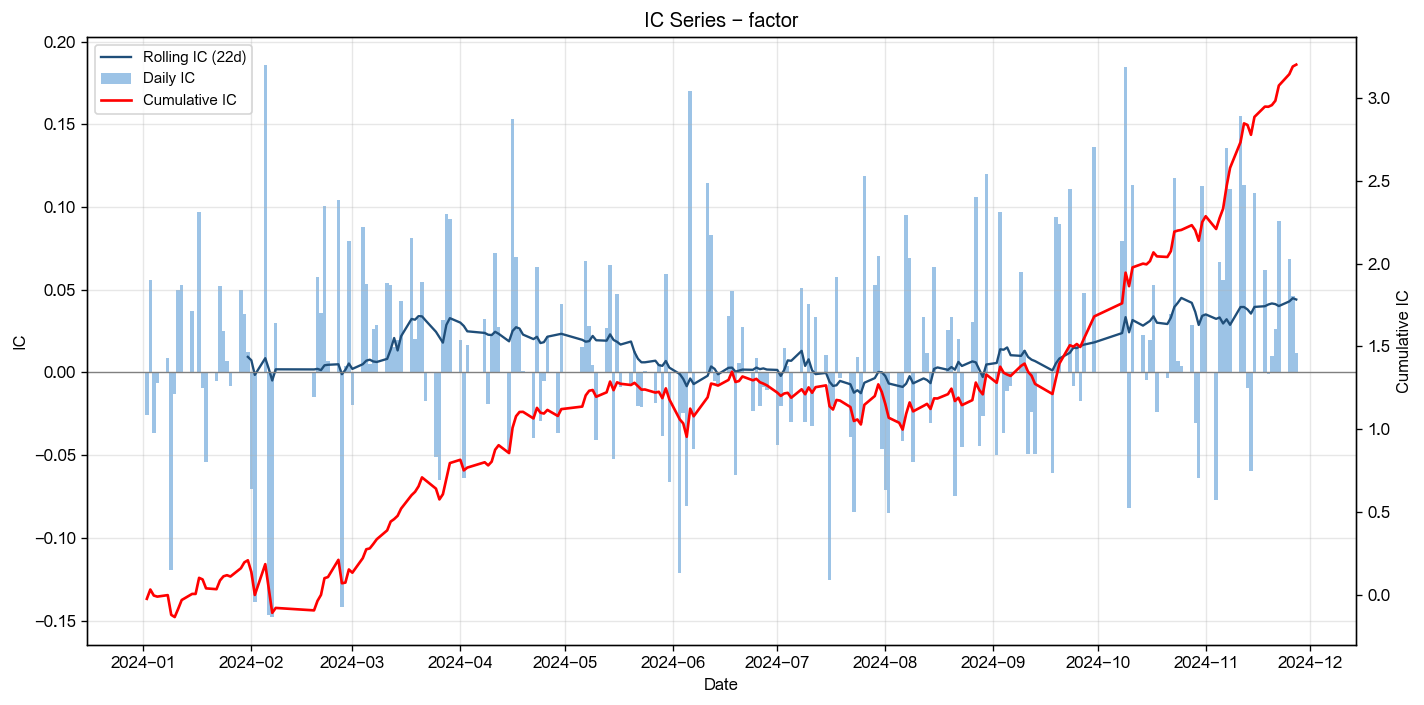
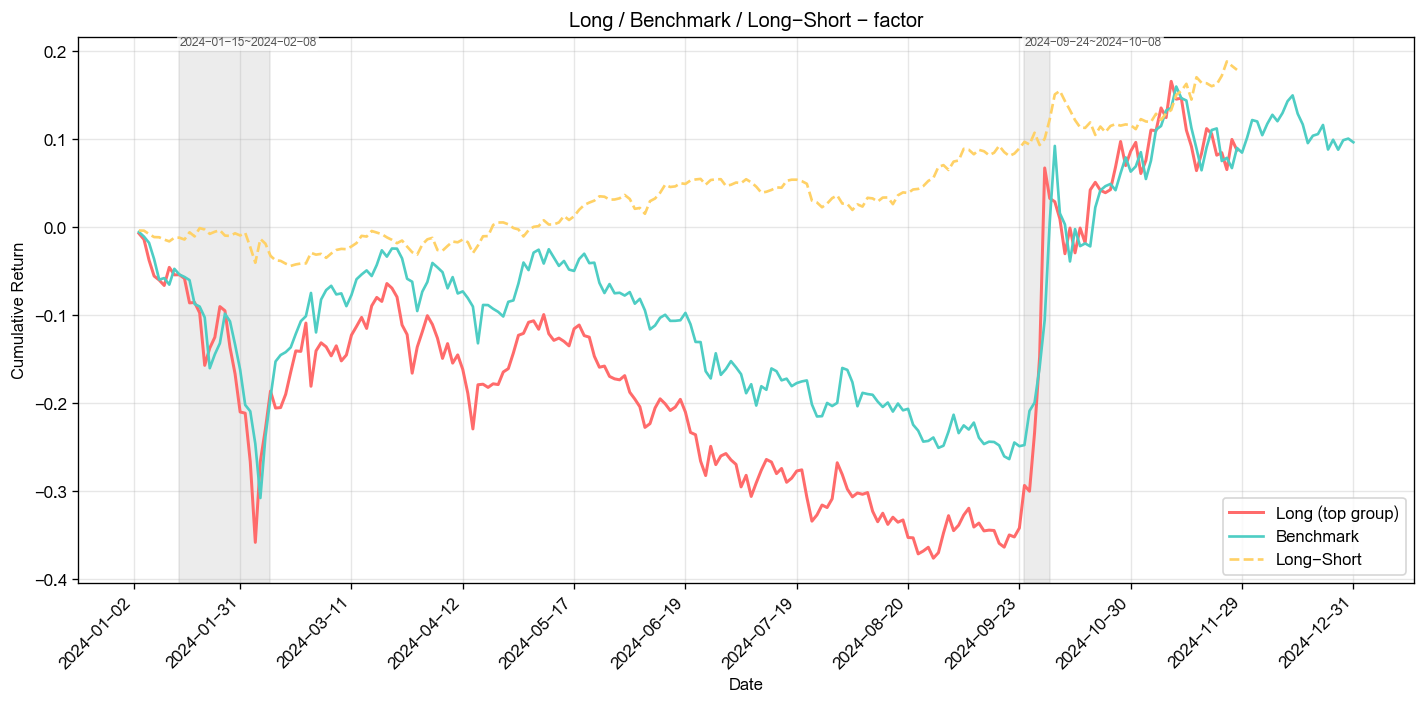
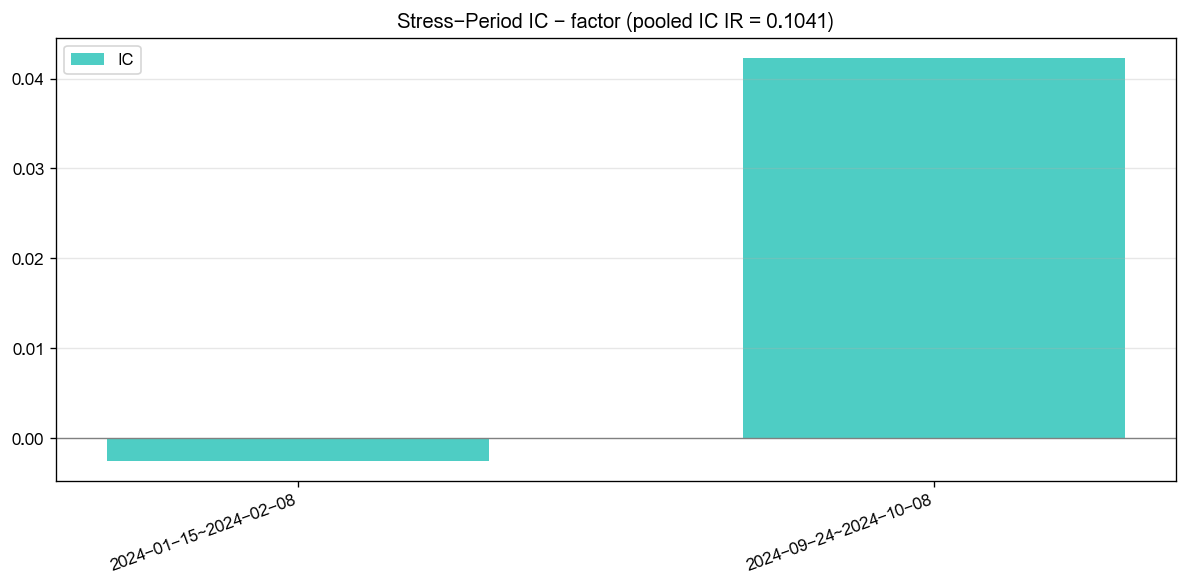
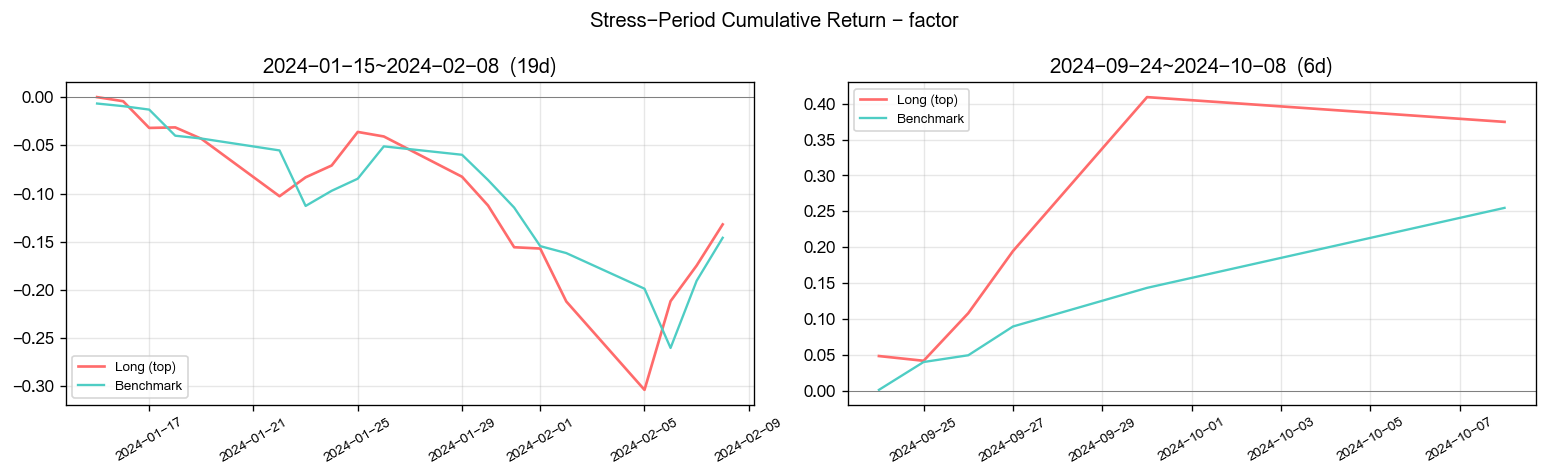

[2026-07-10 03:16:35] [info     ] ========== 因子池回归 ==========
[2026-07-10 03:16:35] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-10 03:16:35] [info     ] 获取收益率数据, 耗时: 0.6273 秒
[2026-07-10 03:16:36] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.6356 秒
[2026-07-10 03:16:36] [info     ] 统计 回归结果, 耗时: 0.1029 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,factor,2.4386,0.0384,0.0157,1.0000
2,rsi_12,1.7877,0.0442,0.0247,1.0000
3,cci_14,1.7852,0.0356,0.0200,1.0000
4,netflow_amount_main,1.5415,0.0257,0.0167,1.0000
5,amount,1.5182,0.0109,0.0072,1.0000
6,netflow_amount_rate_main,1.4851,0.0099,0.0067,1.0000
7,gross_profit_rate_ttm,1.4837,0.0067,0.0045,1.0000
8,net_profit_rate_ttm,1.4563,0.0039,0.0026,0.8000
9,pb,1.4264,0.0098,0.0068,0.9000
10,volume,1.3960,0.0153,0.0109,0.9000

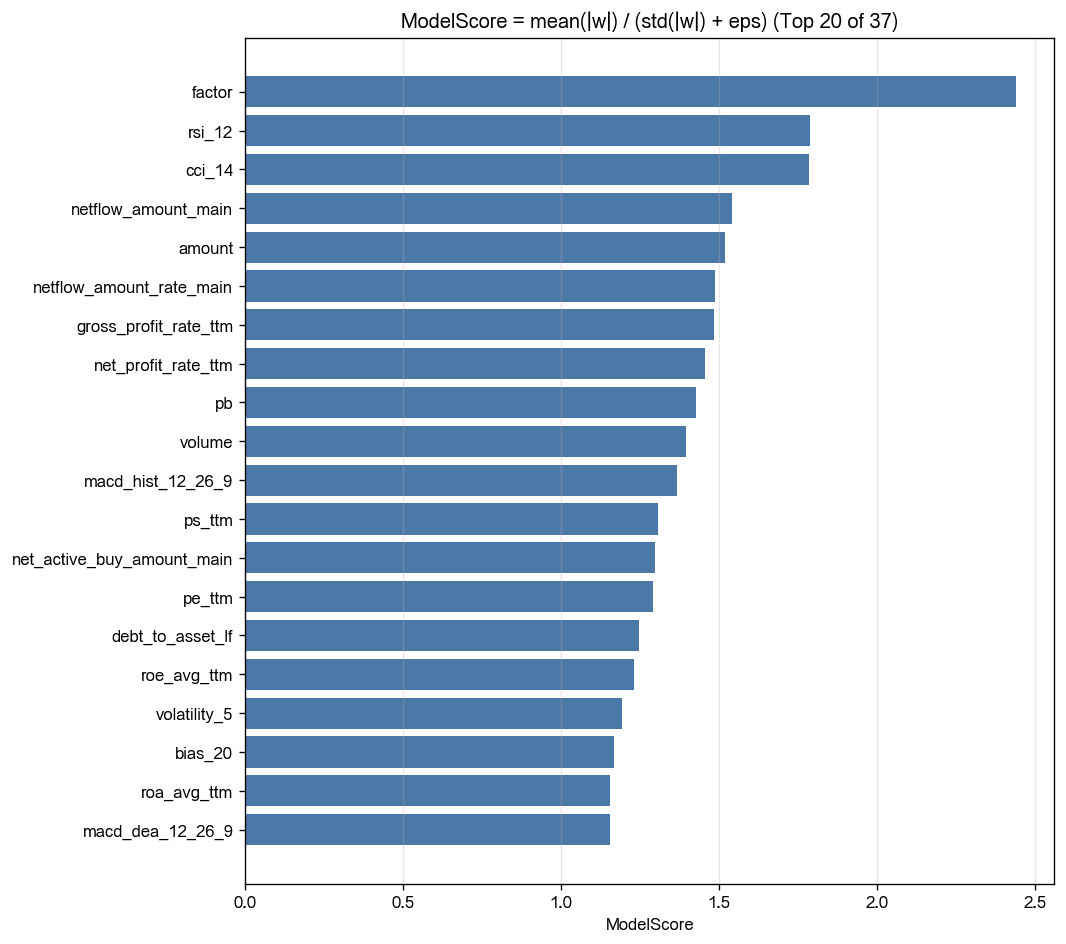
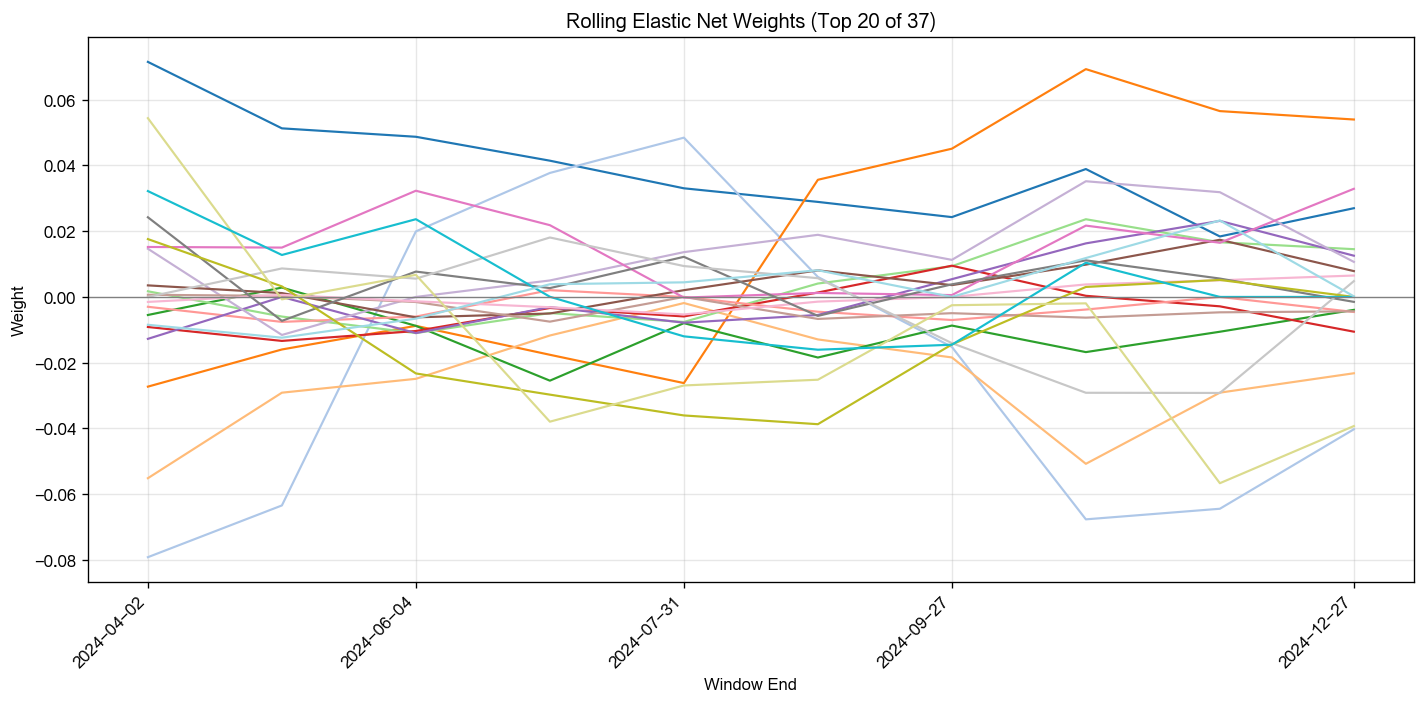
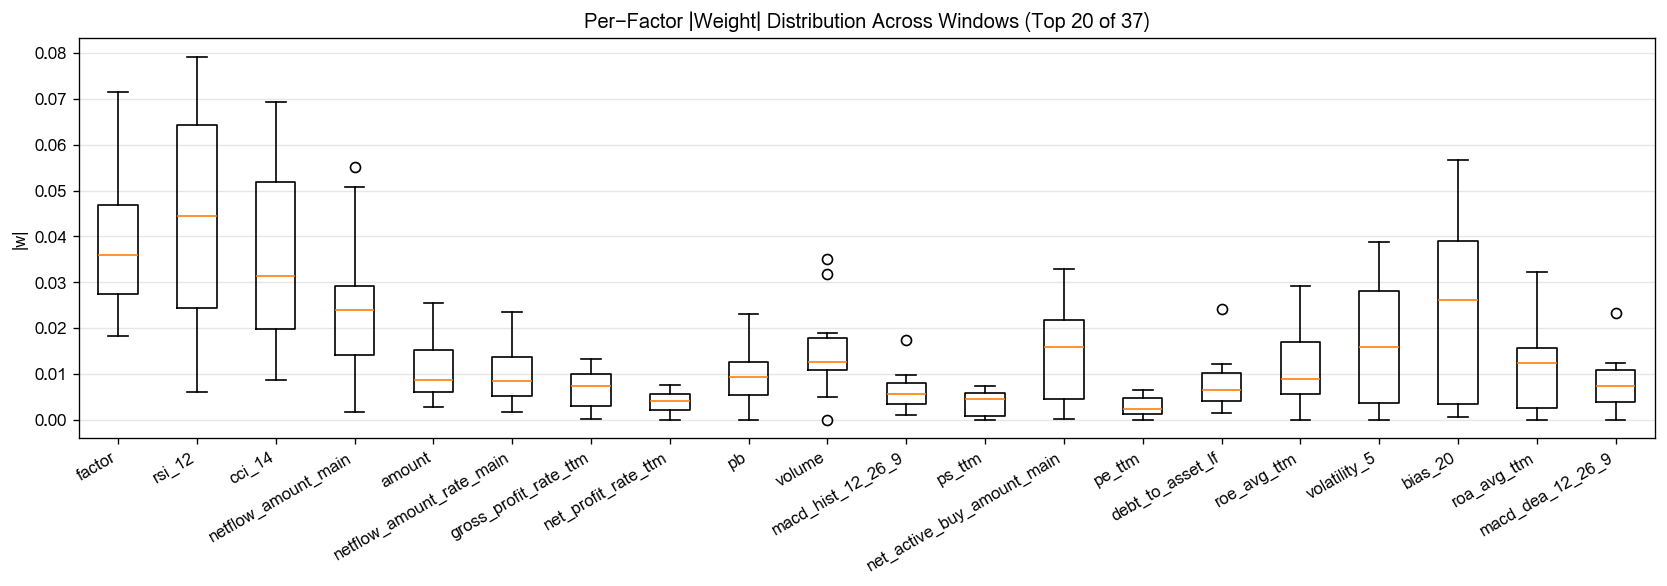
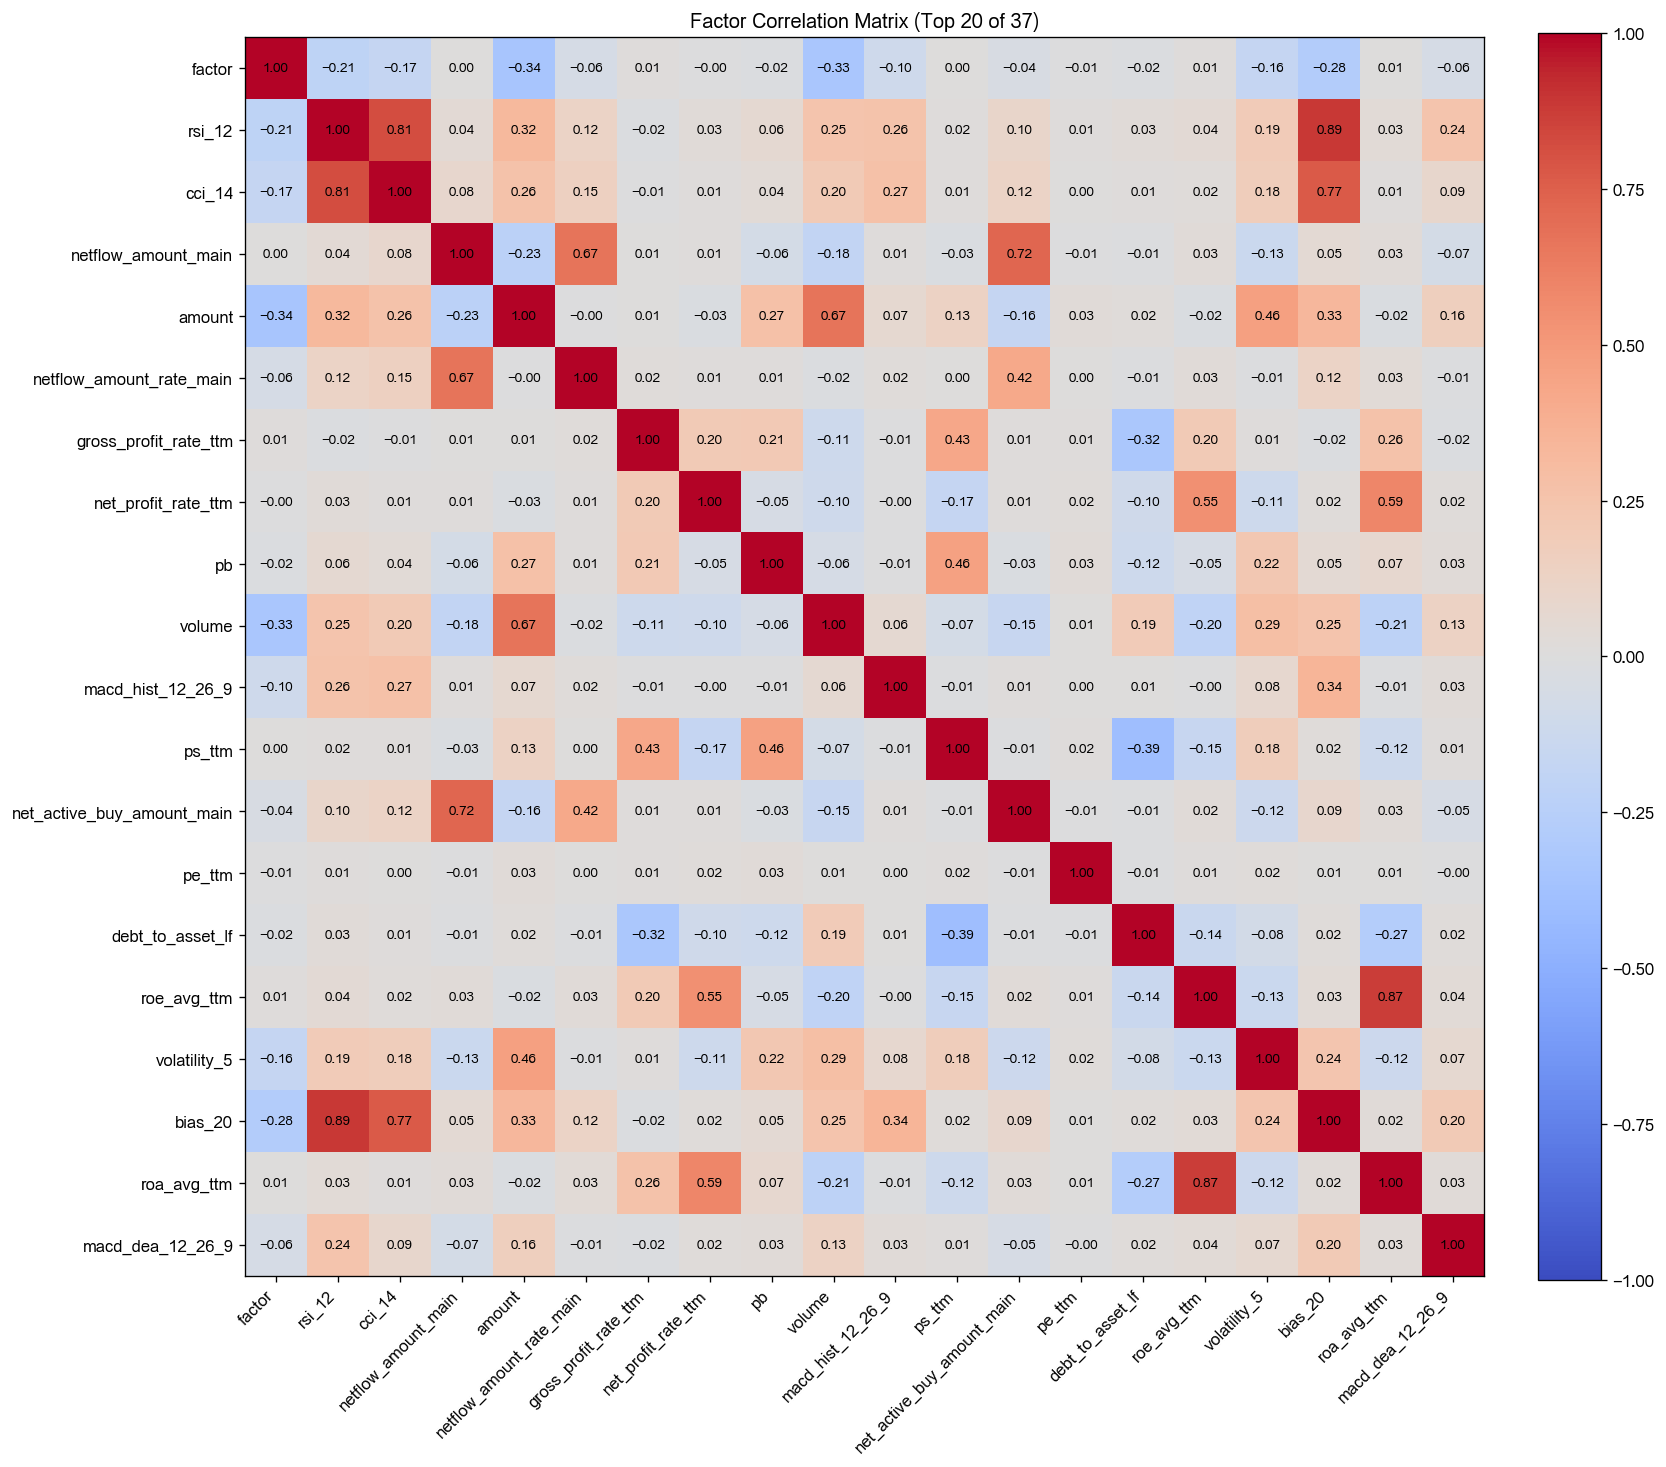

[2026-07-10 03:16:38] [warning  ] 返回的Outputs实例(size=35260464) 大于 64K, 将不会被缓存
[2026-07-10 03:16:38] [info     ] bigalpha_eval.v4 运行完成 [22.207s].


In [1]:
def main(datasources, start_date, end_date):
    import time
    import numpy as np
    import pandas as pd
    import dai
    import lightgbm as lgb
    import structlog
    from sklearn.model_selection import train_test_split
    logger = structlog.get_logger()

    TRAIN_START = '2019-01-01 00:00:00'
    TRAIN_END   = '2023-12-31 23:59:59'

    price_cols = ['open', 'high', 'low', 'close', 'volume', 'amount',
                  'intraday_vol', 'intraday_return', 'close_position', 'buy_pressure',
                  'ret_5d', 'trade_count', 'spread', 'depth_imbalance', 'open_gap',
                  'mid_price_premium', 'turnover_intensity', 'order_size_imbalance',
                  'return_efficiency', 'close_vs_vwap',
                  'depth_resilience', 'total_order_size', 'order_count_imbalance',
                  'bid_slope', 'ask_slope', 'price_pressure']

    fin_cols = ['operating_revenue', 'net_profit_to_parent_shareholders',
                'total_assets', 'total_equity_to_parent_shareholders']

    feature_cols = price_cols + fin_cols + ['roe', 'asset_liability_ratio',
                                            'profit_margin', 'asset_turnover', 'leverage']


    def build_features(financial_table, bar1m_table, sd, ed):
        t0 = time.time()
        logger.info("build_features 开始", start=str(sd), end=str(ed))

        fin_start = pd.to_datetime(sd) - pd.Timedelta(days=365)
        fin_select = ', '.join(fin_cols)
        fin_sql = f"""
        SELECT date, instrument, {fin_select}
        FROM {financial_table}
        WHERE category='lf' AND shift=0
        """
        fin = dai.query(fin_sql, filters={'date': [fin_start, ed]}).df()
        fin['date'] = pd.to_datetime(fin['date'])
        logger.info("财务原始字段查询完成", rows=len(fin), elapsed=round(time.time() - t0, 2))


        t1 = time.time()
        price_start = pd.to_datetime(sd) - pd.Timedelta(days=30)
        price_sql = f"""
        SELECT
            date_trunc('day', date)::DATE           AS trading_day,
            instrument,
            ARG_MIN(open, date)                     AS open,
            MAX(high)                               AS high,
            MIN(low)                                AS low,
            ARG_MAX(close, date)                    AS close,
            SUM(volume)                             AS volume,
            SUM(amount)                             AS amount,
            (MAX(high) - MIN(low)) / (ARG_MIN(open, date) + 0.0001)    AS intraday_vol,
            ARG_MAX(close, date) / (ARG_MIN(open, date) + 0.0001) - 1  AS intraday_return,
            (ARG_MAX(close, date) - MIN(low)) / (MAX(high) - MIN(low) + 0.0001) AS close_position,
            SUM(bid_volume1 + bid_volume2 + bid_volume3 + bid_volume4 + bid_volume5) /
                (SUM(bid_volume1 + bid_volume2 + bid_volume3 + bid_volume4 + bid_volume5) +
                 SUM(ask_volume1 + ask_volume2 + ask_volume3 + ask_volume4 + ask_volume5) + 0.0001) AS buy_pressure,
            SUM(deal_number)                        AS trade_count,
            SUM(deal_number) / (SUM(volume) + 0.0001)                    AS turnover_intensity,
            (SUM(bid_volume1) / (SUM(bid_num_orders1) + 0.0001)) /
                (SUM(ask_volume1) / (SUM(ask_num_orders1) + 0.0001) + 0.0001) AS order_size_imbalance,
            AVG((ask_price1 - bid_price1) / (close + 0.0001))          AS spread,
            SUM(close * volume) / (SUM(volume) + 0.0001)                       AS vwap,
            AVG(bid_price1 - bid_price5) / (AVG(close) + 0.0001)            AS bid_slope,
            AVG(ask_price5 - ask_price1) / (AVG(close) + 0.0001)            AS ask_slope,
            (AVG(bid_price1) + AVG(ask_price1)) / 2 / (AVG(close) + 0.0001) - 1 AS price_pressure,
            (SUM(bid_volume1 + bid_volume2 + bid_volume3 + bid_volume4 + bid_volume5) +
             SUM(ask_volume1 + ask_volume2 + ask_volume3 + ask_volume4 + ask_volume5)) /
                (SUM(volume) + 0.0001) AS depth_resilience,
            (SUM(bid_volume1 + bid_volume2 + bid_volume3 + bid_volume4 + bid_volume5) +
             SUM(ask_volume1 + ask_volume2 + ask_volume3 + ask_volume4 + ask_volume5)) /
                (SUM(bid_num_orders1 + bid_num_orders2 + bid_num_orders3 + bid_num_orders4 + bid_num_orders5 +
                     ask_num_orders1 + ask_num_orders2 + ask_num_orders3 + ask_num_orders4 + ask_num_orders5) + 0.0001) AS total_order_size,
            SUM(bid_num_orders1 + bid_num_orders2 + bid_num_orders3 + bid_num_orders4 + bid_num_orders5) /
                (SUM(ask_num_orders1 + ask_num_orders2 + ask_num_orders3 + ask_num_orders4 + ask_num_orders5) + 0.0001) AS order_count_imbalance,
            (SUM(bid_volume1) + SUM(bid_volume2) + SUM(bid_volume3) + SUM(bid_volume4) + SUM(bid_volume5)) /
                (SUM(bid_volume1) + SUM(bid_volume2) + SUM(bid_volume3) + SUM(bid_volume4) + SUM(bid_volume5) +
                 SUM(ask_volume1) + SUM(ask_volume2) + SUM(ask_volume3) + SUM(ask_volume4) + SUM(ask_volume5) + 0.0001) AS depth_imbalance,
            (ARG_MIN(open, date) - ARG_MIN(pre_close, date)) / (ARG_MIN(pre_close, date) + 0.0001) AS open_gap,
            (SUM(bid_price1 * bid_volume1 + bid_price2 * bid_volume2 + bid_price3 * bid_volume3 + bid_price4 * bid_volume4 + bid_price5 * bid_volume5) /
                (SUM(bid_volume1 + bid_volume2 + bid_volume3 + bid_volume4 + bid_volume5) + 0.0001) +
             SUM(ask_price1 * ask_volume1 + ask_price2 * ask_volume2 + ask_price3 * ask_volume3 + ask_price4 * ask_volume4 + ask_price5 * ask_volume5) /
                (SUM(ask_volume1 + ask_volume2 + ask_volume3 + ask_volume4 + ask_volume5) + 0.0001)) / 2 / (AVG(close) + 0.0001) - 1 AS mid_price_premium
        FROM {bar1m_table}
        GROUP BY trading_day, instrument
        ORDER BY trading_day, instrument
        """
        price = dai.query(price_sql, filters={'date': [price_start, ed]}).df().rename(columns={'trading_day': 'date'})
        price['date'] = pd.to_datetime(price['date'])
        price = price.sort_values(['instrument', 'date']).reset_index(drop=True)
        price['close_vs_vwap'] = price['close'] / price['vwap'] - 1
        logger.info("量价原始字段查询完成", rows=len(price), elapsed=round(time.time() - t1, 2))


        t2 = time.time()
        g = price.groupby('instrument', group_keys=False)['close']

        price['label'] = g.shift(-1) / price['close'] - 1

        g_close = price.groupby('instrument', group_keys=False)['close']
        price['ret_5d'] = g_close.pct_change(5)
        logger.info("标签计算完成", elapsed=round(time.time() - t2, 2))


        all_dates = pd.date_range(fin_start, pd.Timestamp(ed))
        all_inst = fin['instrument'].unique()
        full_idx = pd.MultiIndex.from_product(
            [all_inst, all_dates], names=['instrument', 'date']
        )
        fin = (fin.set_index(['instrument', 'date'])
                  .reindex(full_idx)
                  .groupby(level='instrument')
                  .ffill()
                  .reset_index())
        logger.info("财务日历填充完成", total_calendar=len(full_idx))

        df = pd.merge(price, fin, how='inner', on=['date', 'instrument'])

        eps = 1e-8
        df['roe'] = df['net_profit_to_parent_shareholders'] / (df['total_equity_to_parent_shareholders'] + eps)
        df['asset_liability_ratio'] = (df['total_assets'] - df['total_equity_to_parent_shareholders']) / (df['total_assets'] + eps)
        df['profit_margin']  = df['net_profit_to_parent_shareholders'] / (df['operating_revenue'] + eps)
        df['asset_turnover'] = df['operating_revenue'] / (df['total_assets'] + eps)
        df['leverage']       = df['total_assets'] / (df['total_equity_to_parent_shareholders'] + eps)

        df['return_efficiency'] = df['intraday_return'] / (df['intraday_vol'] + eps)


        t_exp = time.time()
        exposure = dai.query(
            "SELECT * FROM bigalpha_2026_exposure",
            filters={'date': [sd, ed]},
        ).df()
        exposure['date'] = pd.to_datetime(exposure['date'])
        exposure['instrument'] = exposure['instrument'].astype(str)
        exposure_value_cols = [c for c in exposure.columns if c not in ('date', 'instrument')]
        df = pd.merge(df, exposure, how='left', on=['date', 'instrument'])
        for c in exposure_value_cols:
            if c not in feature_cols:
                feature_cols.append(c)
        logger.info("BARRA暴露合并完成", exp_cols=len(exposure_value_cols),
                    elapsed=round(time.time() - t_exp, 2))


        t_1d = time.time()
        bar1d = dai.query(
            "SELECT * FROM bigalpha_2026_bar1d",
            filters={'date': [sd, ed]},
        ).df()
        bar1d['date'] = pd.to_datetime(bar1d['date'])
        bar1d['instrument'] = bar1d['instrument'].astype(str)
        bar1d_new_cols = [c for c in bar1d.columns
                          if c not in ('date', 'instrument') and c not in df.columns]
        if bar1d_new_cols:
            df = pd.merge(df, bar1d[['date', 'instrument'] + bar1d_new_cols],
                         how='left', on=['date', 'instrument'])
            for c in bar1d_new_cols:
                if c not in feature_cols:
                    feature_cols.append(c)
        logger.info("日行情合并完成", new_cols=len(bar1d_new_cols),
                    elapsed=round(time.time() - t_1d, 2))


        t3 = time.time()
        for col in feature_cols:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[col] = df[col].replace([np.inf, -np.inf], np.nan)
        logger.info("缺失值处理完成", elapsed=round(time.time() - t3, 2))


        df = df[(df['date'] >= pd.to_datetime(sd)) & (df['date'] <= pd.to_datetime(ed))]
        logger.info("build_features 结束", rows=len(df), total_elapsed=round(time.time() - t0, 2))
        return df.reset_index(drop=True)


    logger.info("开始构建训练集", train_start=TRAIN_START, train_end=TRAIN_END)
    train_df = build_features('bigalpha_2026_financial', 'bigalpha_2026_stock_bar1m', TRAIN_START, TRAIN_END)
    train_df['label'] = train_df['label'].replace([np.inf, -np.inf], np.nan)
    train_df = train_df.dropna(subset=['label'])


    t_corr = time.time()
    corr_cols = [c for c in feature_cols if c in train_df.columns]
    corr_matrix = train_df[corr_cols].corr().abs().fillna(0)
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = set()
    for col in upper.columns:
        if upper[col].max() > 0.85:
            to_drop.add(col)
    feature_cols_filtered = [c for c in corr_cols if c not in to_drop]
    logger.info("去共线性完成", removed=len(to_drop), kept=len(feature_cols_filtered),
                elapsed=round(time.time() - t_corr, 2))


    t_fit = time.time()
    train_part, val_part = train_test_split(train_df, test_size=0.2, shuffle=False)
    logger.info("开始训练模型", train_samples=len(train_part), val_samples=len(val_part))

    model = lgb.LGBMRegressor(
        n_estimators=300,
        num_leaves=15,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.7,
        feature_fraction=0.7,
        min_child_samples=20,
        reg_lambda=5.0,
        reg_alpha=1.0,
        max_bin=128,
        n_jobs=-1,
        random_state=42,
        early_stopping_round=30,
        verbose=-1,
    )
    model.fit(
        train_part[feature_cols_filtered], train_part['label'],
        eval_set=[(val_part[feature_cols_filtered], val_part['label'])],
        eval_metric='rmse',
    )
    logger.info("模型训练完成", elapsed=round(time.time() - t_fit, 2))


    logger.info("开始构建测试集并预测")
    bar1m_table = datasources['bar1m']
    financial_table = datasources['financial']
    test_df = build_features(financial_table, bar1m_table, start_date, end_date)

    pred_cols = [c for c in feature_cols_filtered if c in test_df.columns]
    test_df['factor'] = model.predict(test_df[pred_cols])


    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [start_date, end_date]},
    ).df()
    stk_pool['instrument'] = stk_pool['instrument'].astype(str)

    result = pd.merge(test_df[['date', 'instrument', 'factor']], stk_pool,
                    how='inner', on=['date', 'instrument'])
    result['factor'] = result['factor'].replace([np.inf, -np.inf], np.nan)
    result = result.dropna(subset=['factor']).reset_index(drop=True)[['date', 'instrument', 'factor']]

    logger.info("因子构建完成", rows=len(result))
    return result


if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    datasources = {
        'bar1m': 'bigalpha_2026_stock_bar1m',
        'financial': 'bigalpha_2026_financial'
    }
    start_date = '2024-01-01 00:00:00'
    end_date   = '2024-12-31 23:59:59'

    logger.info(f"计算因子，测试区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )
